In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILES = [
    "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/thai_data/thai_aws_airnow.nc",
    "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/philippines_data/philippines_aws_airnow.nc"
    
    # "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/thai_data/thai_aws_airnow_qc.nc",
    # "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/philippines_data/philippines_aws_airnow_qc.nc"

]




In [8]:
# ds = xr.open_dataset("/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/philippines_data/philippines_aws_airnow.nc")
# print(ds)

# ds[list(ds.data_vars)[5]].isel(time=slice(0, 10000)).plot()


PROCESSING: /glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/thai_data/thai_aws_airnow.nc

/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/thai_data/thai_aws_airnow.nc
<xarray.Dataset> Size: 22MB
Dimensions:              (x: 70, time: 3640)
Coordinates:
  * x                    (x) int64 560B 0 1 2 3 4 5 6 7 ... 63 64 65 66 67 68 69
    siteid               (x) <U5 1kB ...
    latitude             (x) float64 560B ...
    longitude            (x) float64 560B ...
    utcoffset            (x) float64 560B ...
  * time                 (time) datetime64[ns] 29kB 2024-01-01 ... 2024-05-31...
Data variables:
    CO                   (x, time) float64 2MB ...
    NO2                  (x, time) float64 2MB ...
    O3                   (x, time) float64 2MB ...
    PM10                 (x, time) float64 2MB ...
   

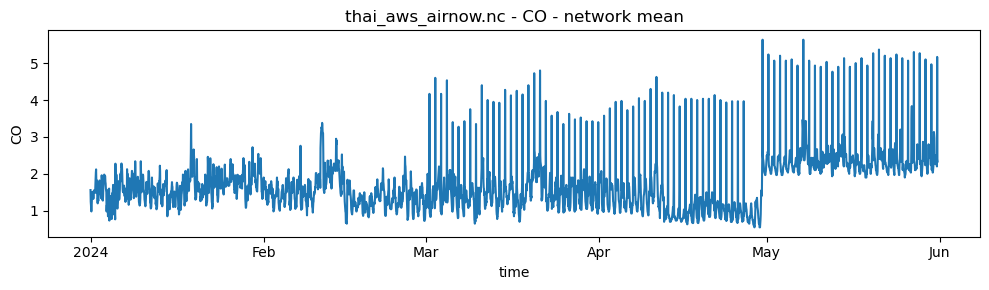

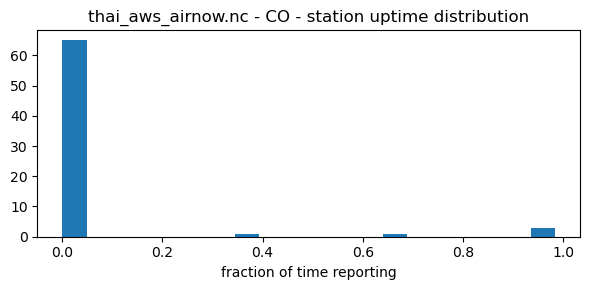

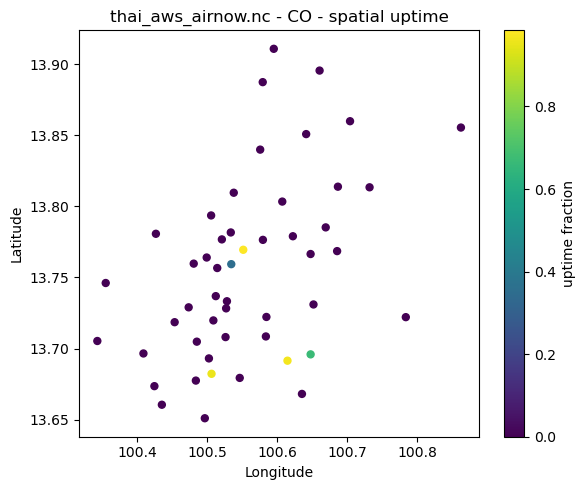

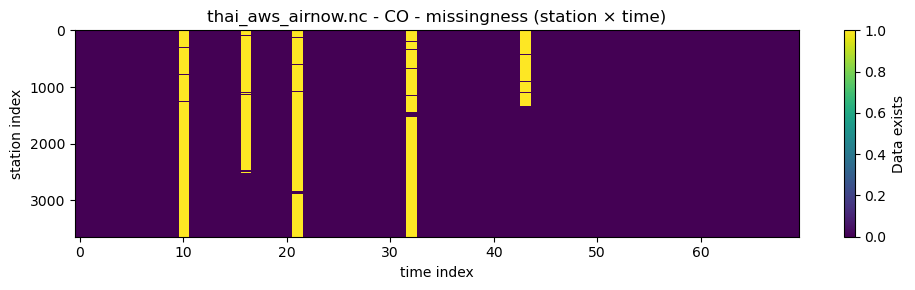

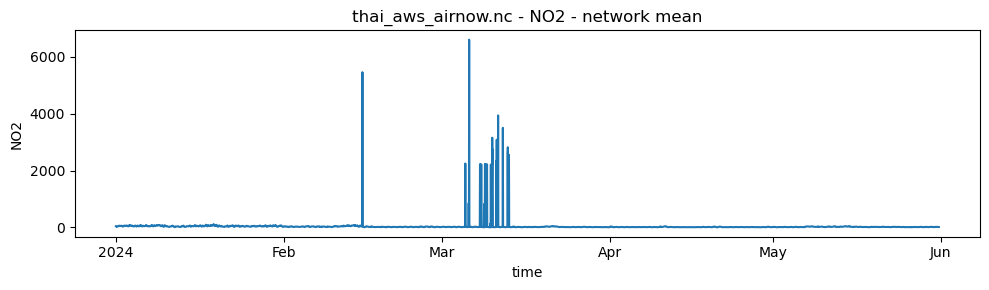

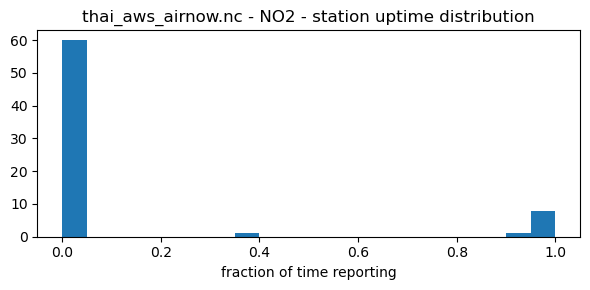

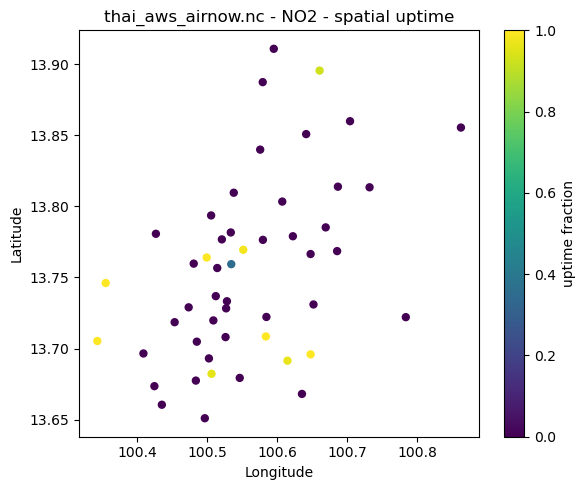

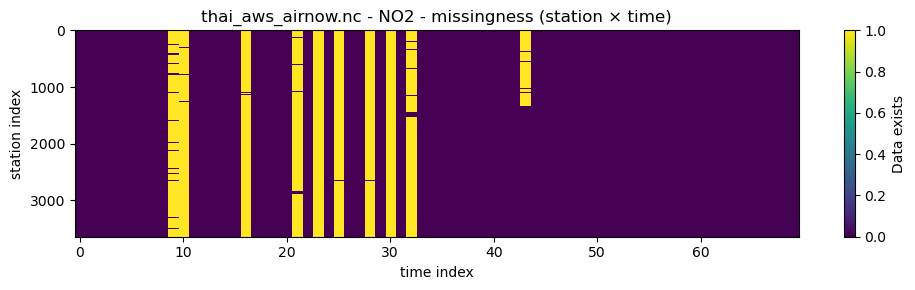

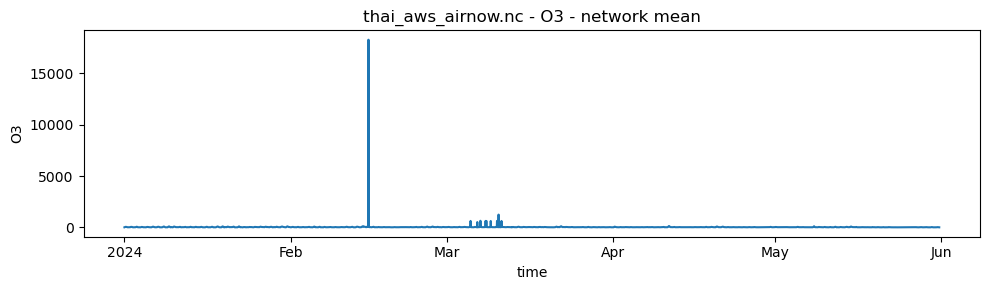

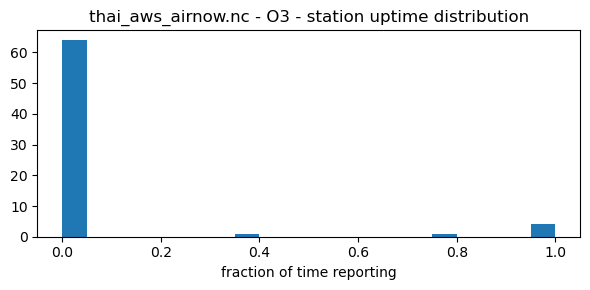

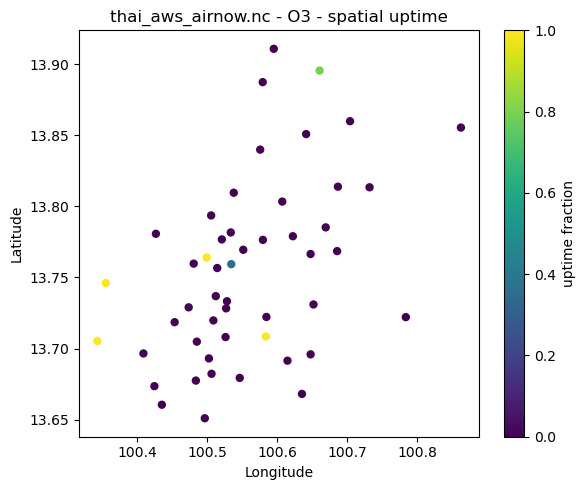

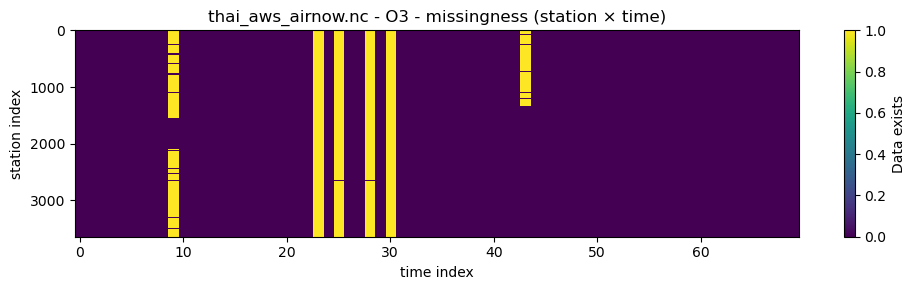

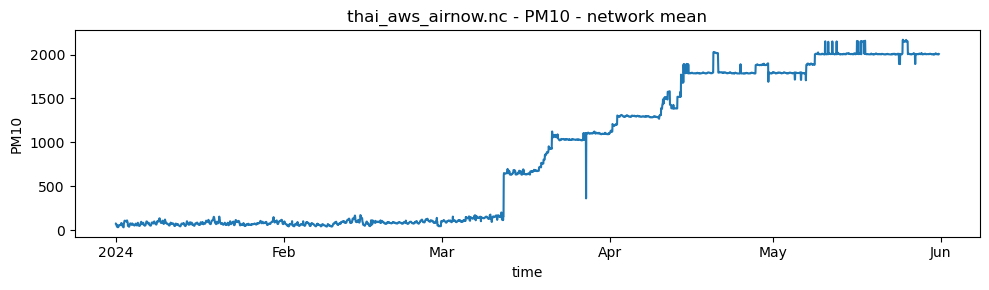

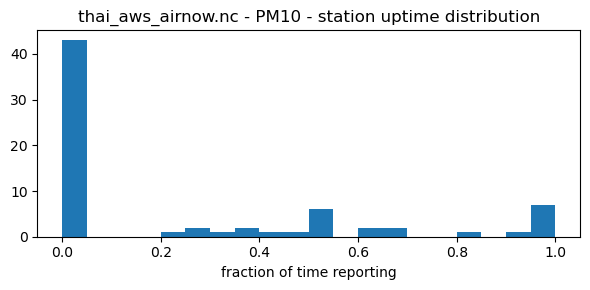

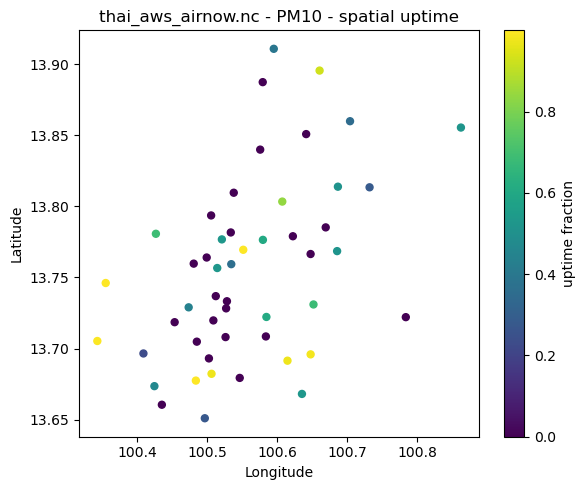

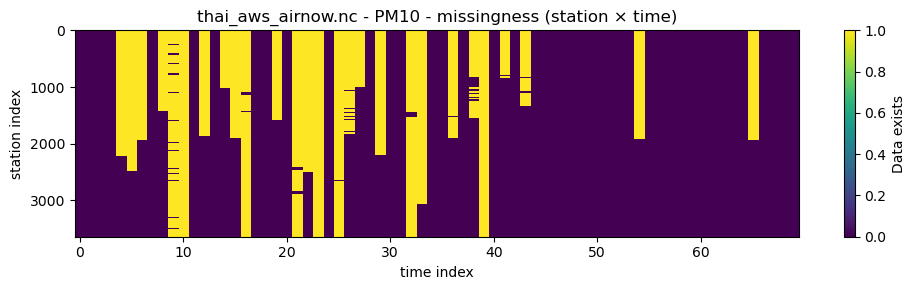

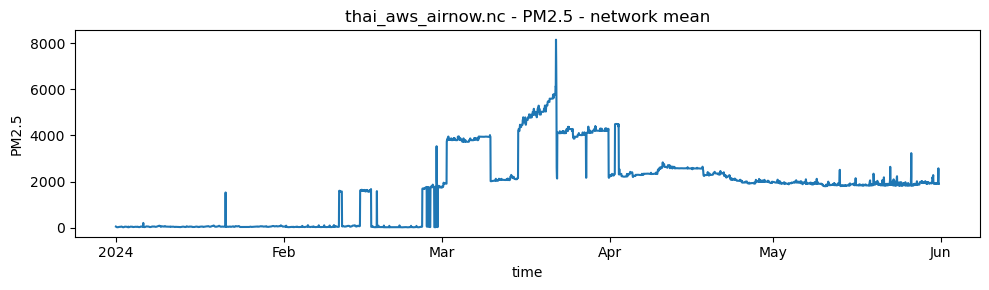

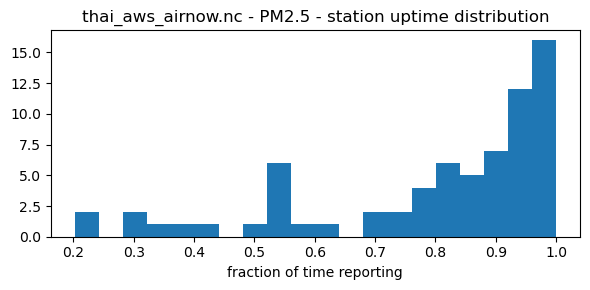

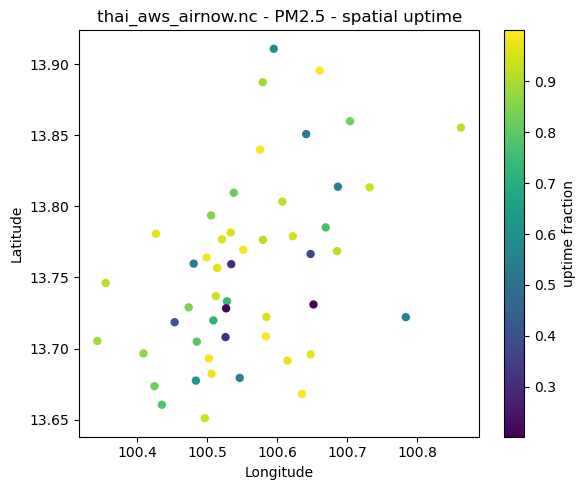

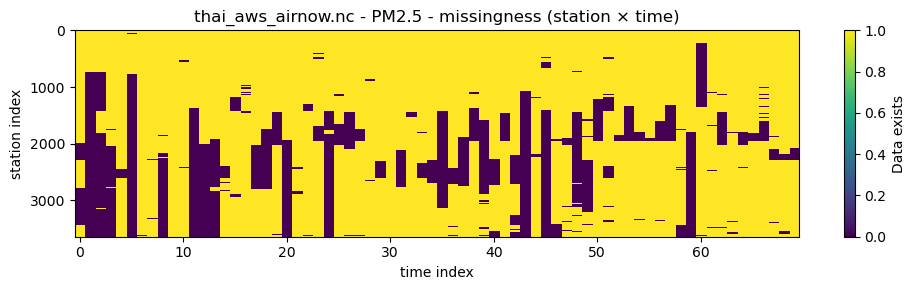

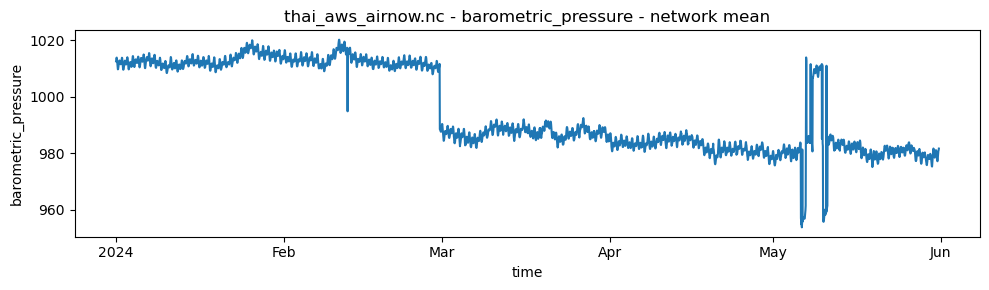

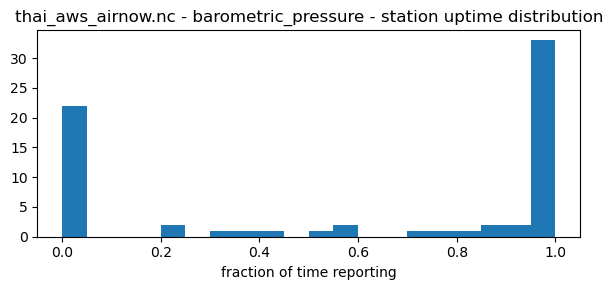

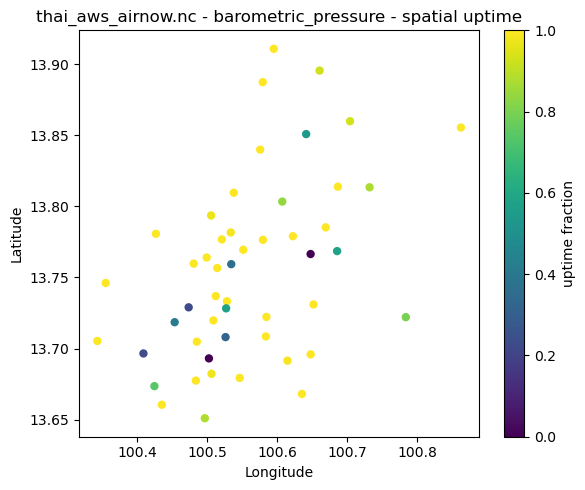

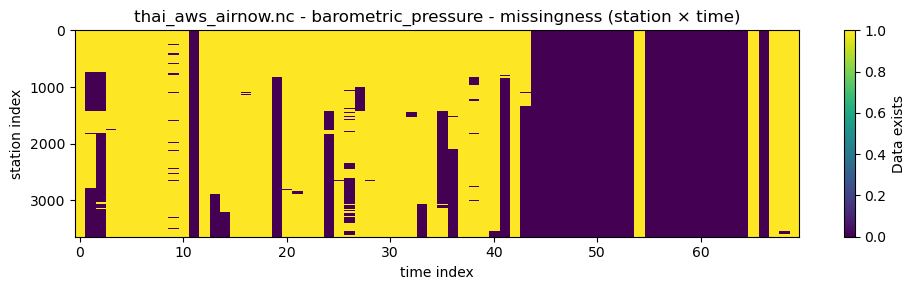

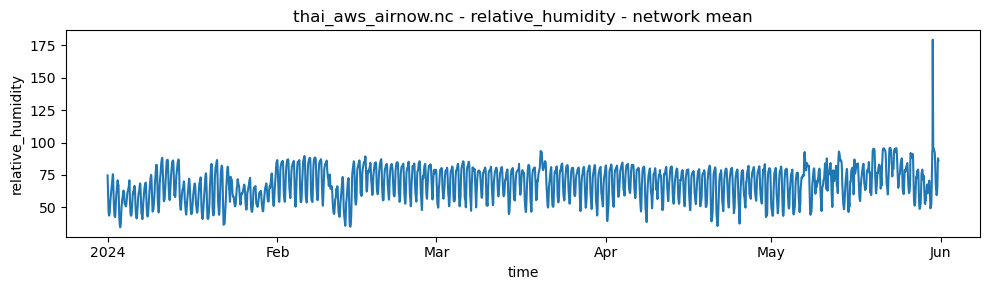

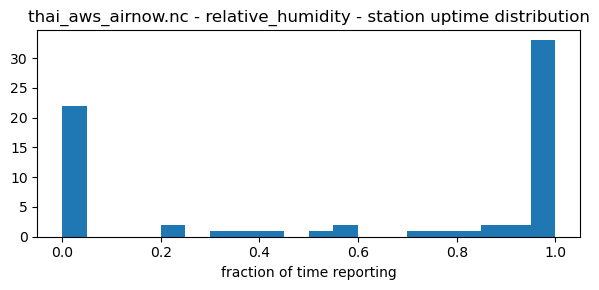

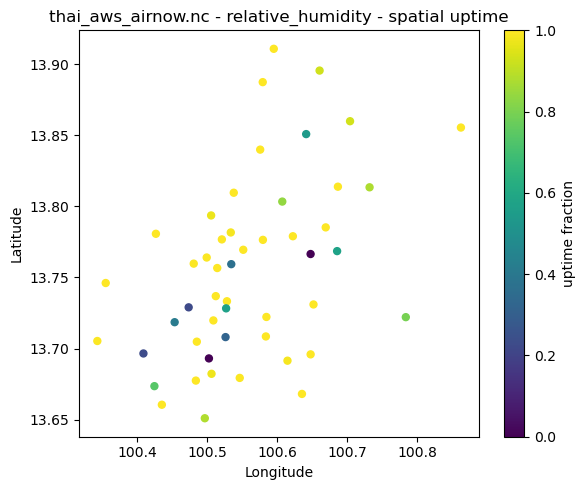

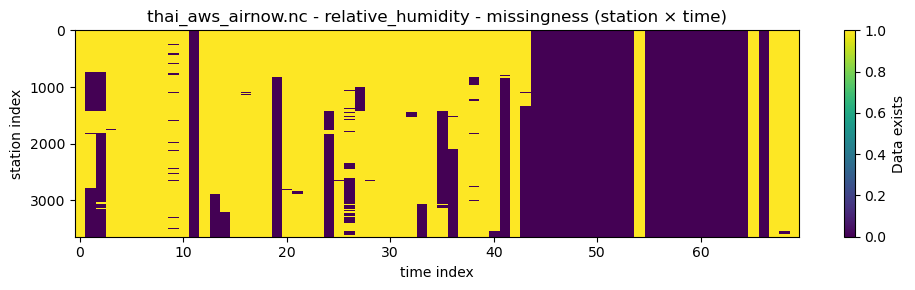

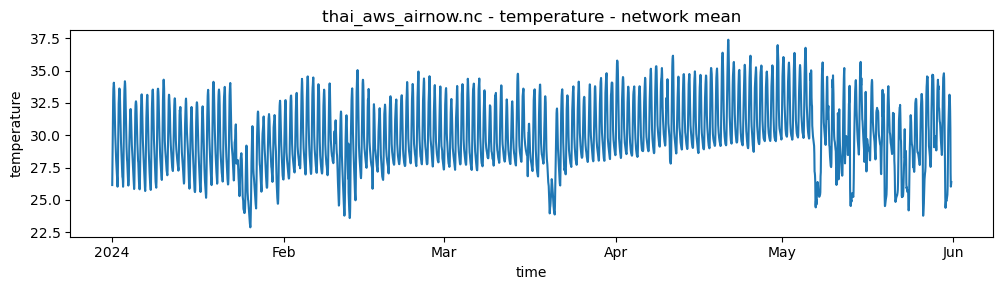

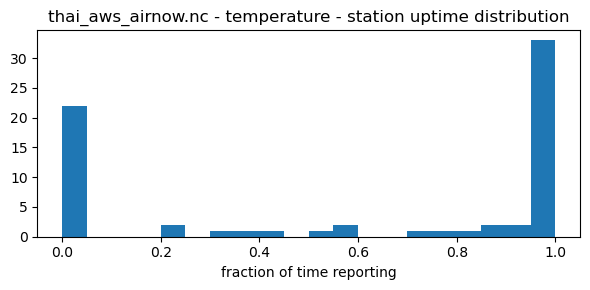

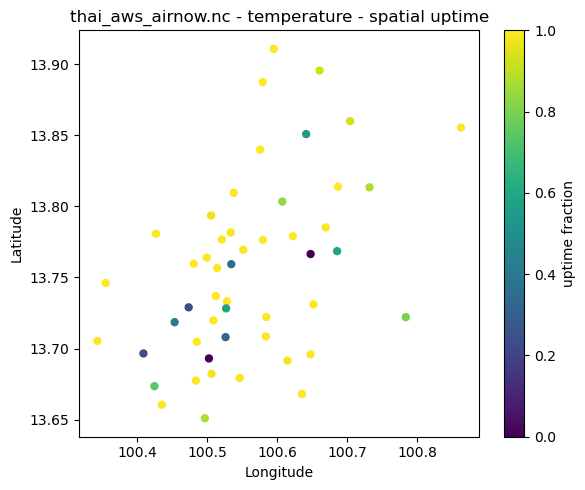

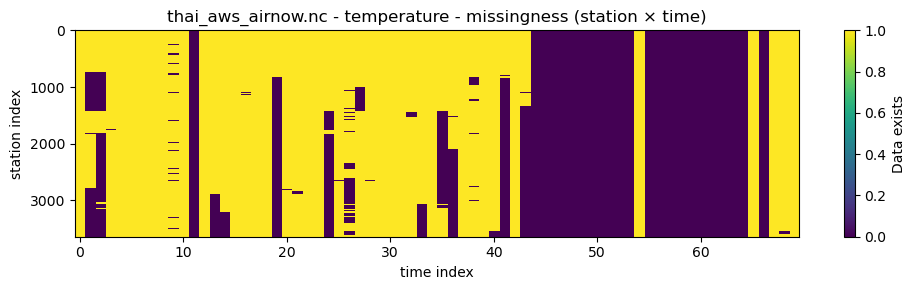

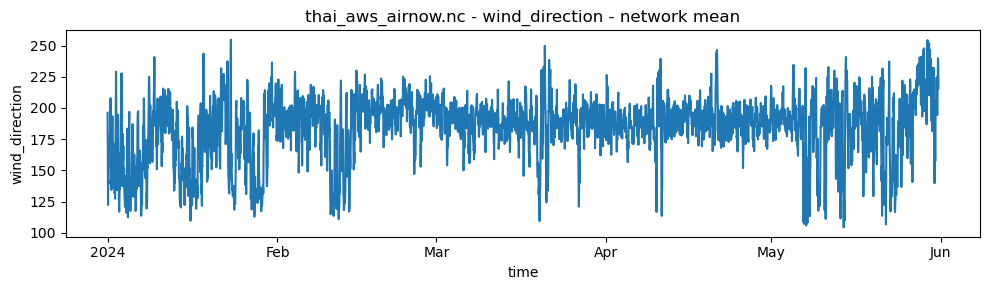

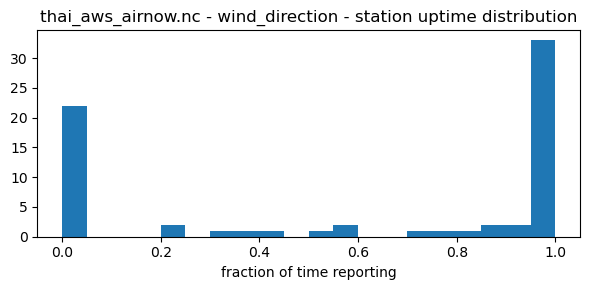

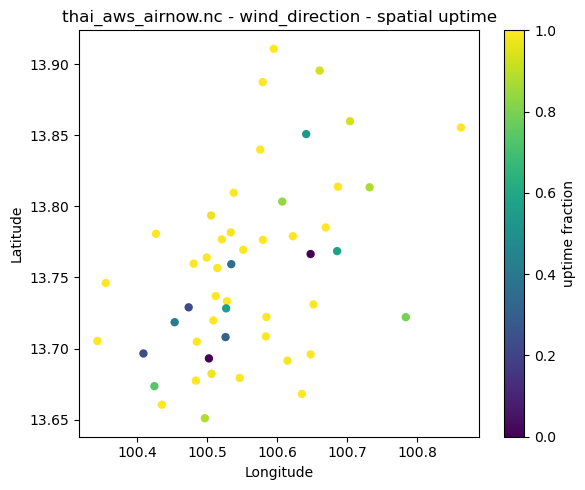

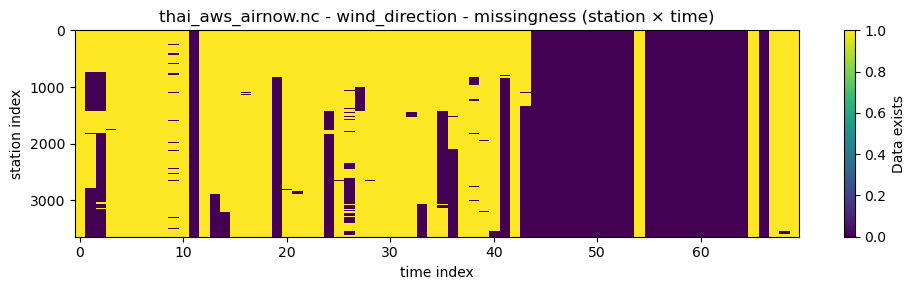

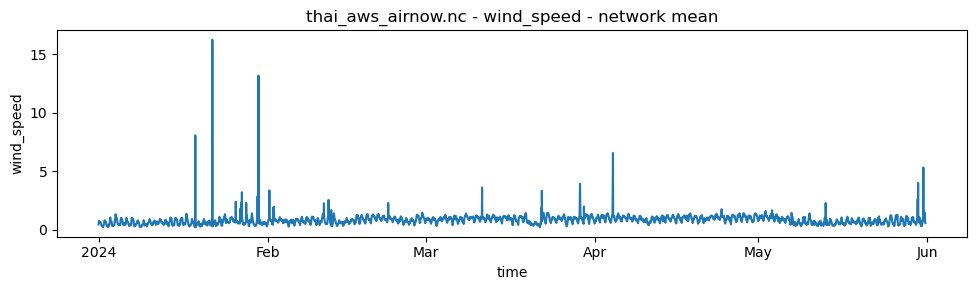

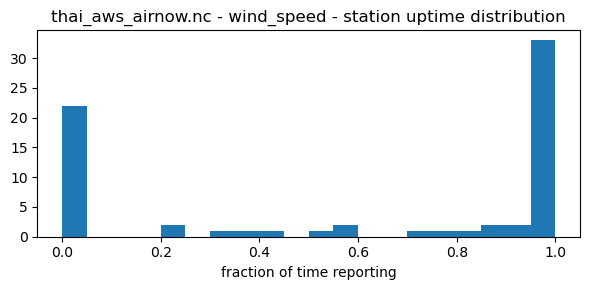

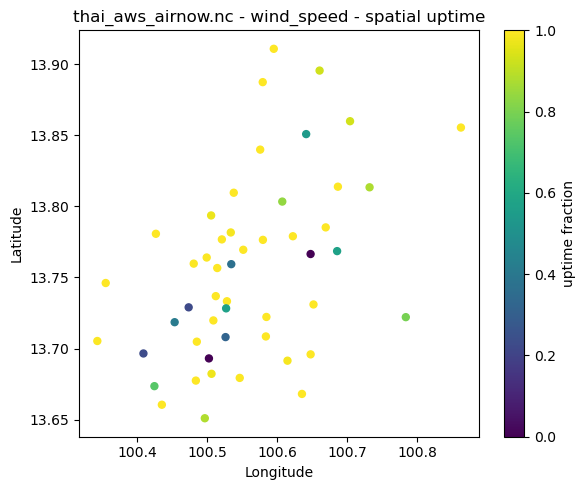

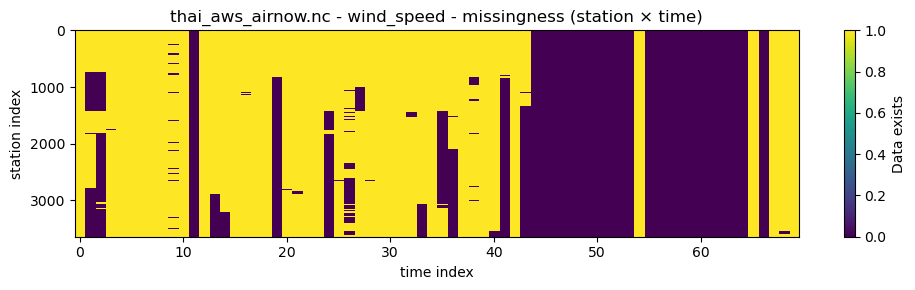


PROCESSING: /glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/philippines_data/philippines_aws_airnow.nc

/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/philippines_data/philippines_aws_airnow.nc
<xarray.Dataset> Size: 12MB
Dimensions:            (time: 3648, x: 46)
Coordinates:
  * time               (time) datetime64[ns] 29kB 2024-01-01 ... 2024-05-31T2...
  * x                  (x) int64 368B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45
    siteid             (x) <U9 2kB ...
    latitude           (x) float64 368B ...
    longitude          (x) float64 368B ...
    utcoffset          (x) float64 368B ...
Data variables:
    dewpoint           (time, x) float64 1MB ...
    precip_accum       (time, x) float64 1MB ...
    relative_humidity  (time, x) float64 1MB ...
    solar_radiation    (time, x) float64 1MB

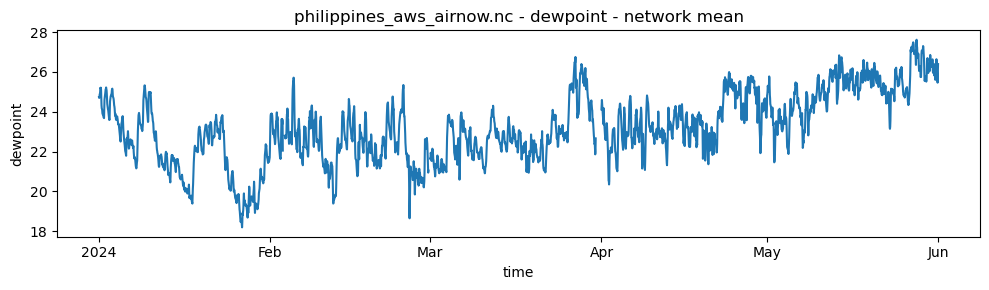

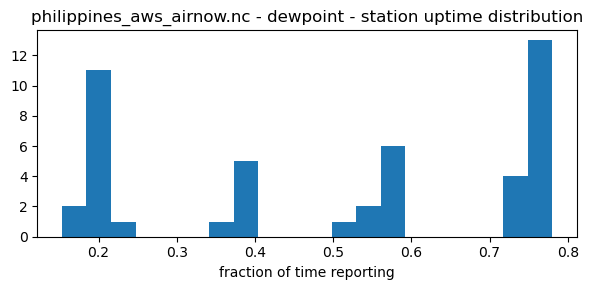

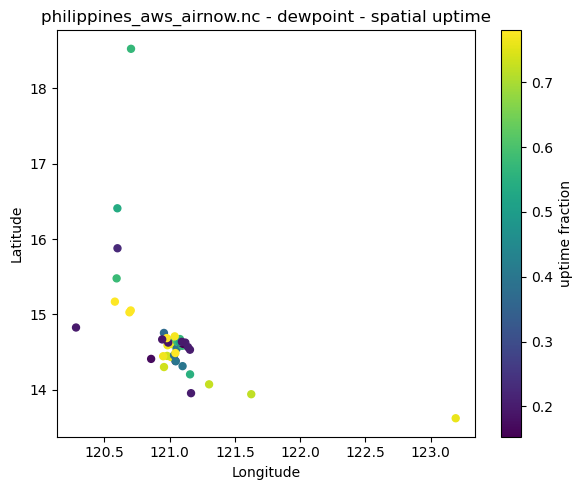

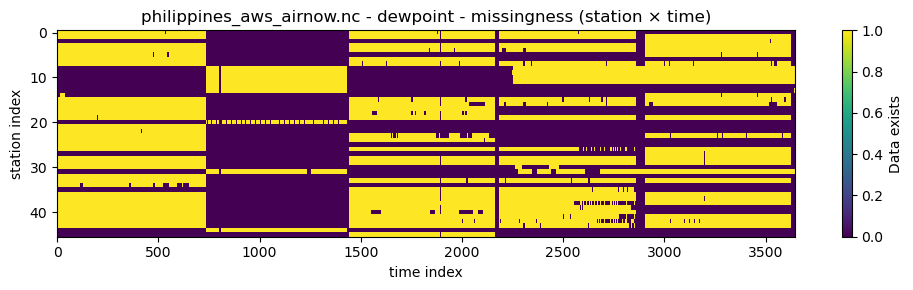

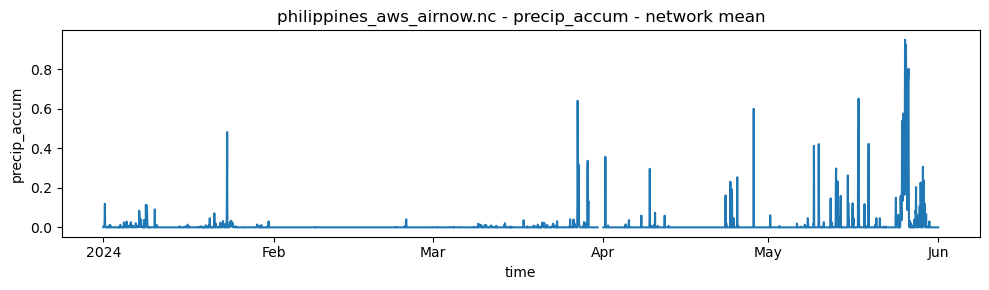

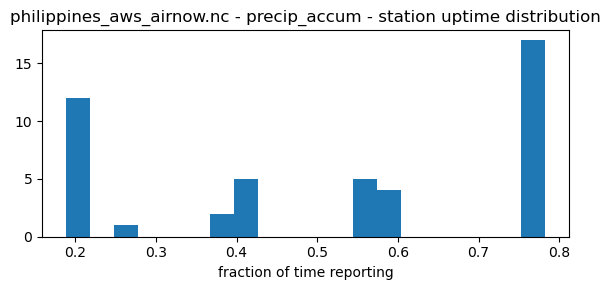

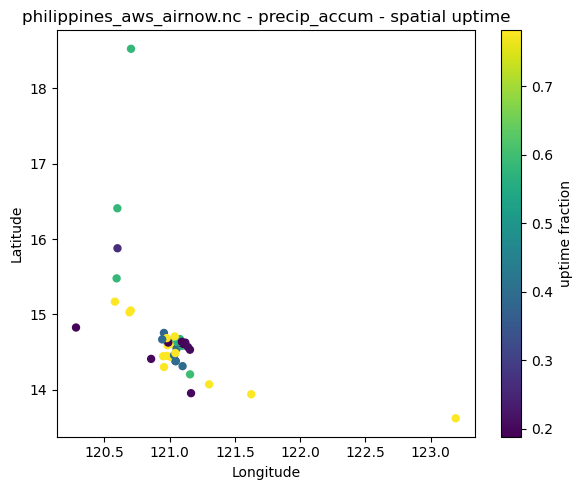

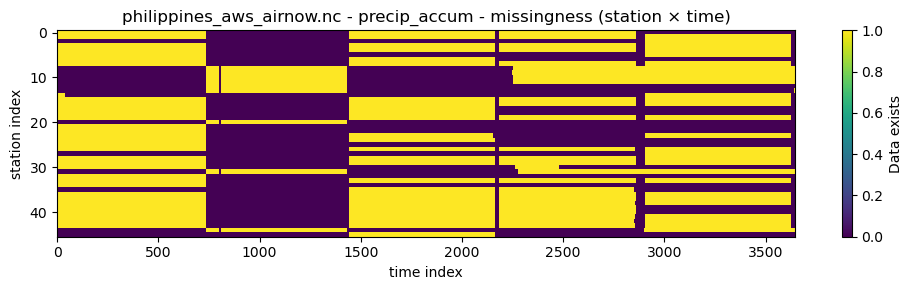

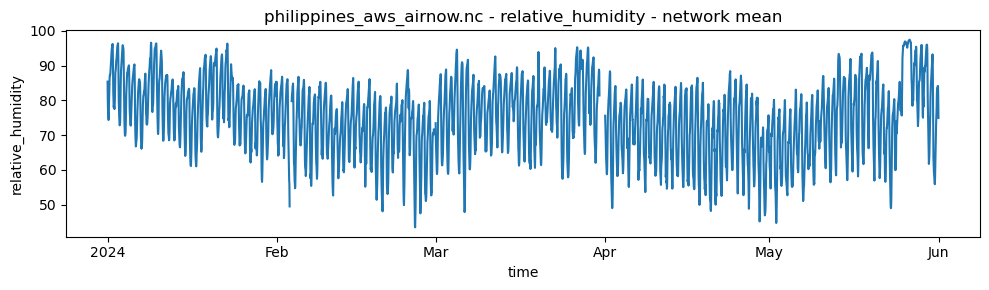

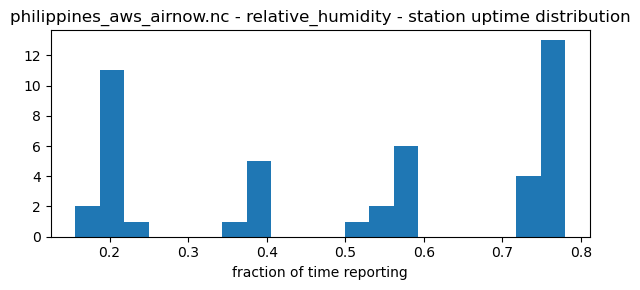

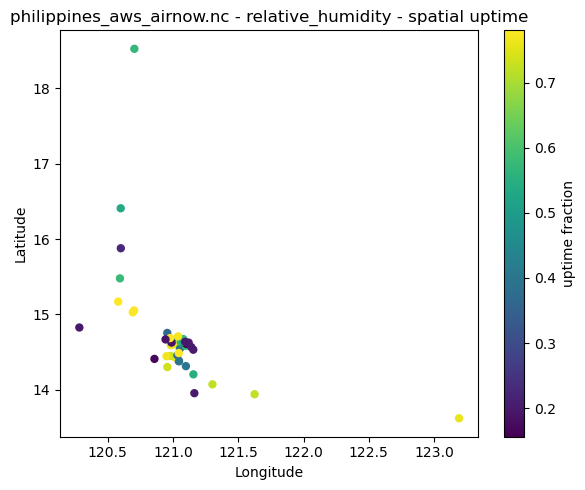

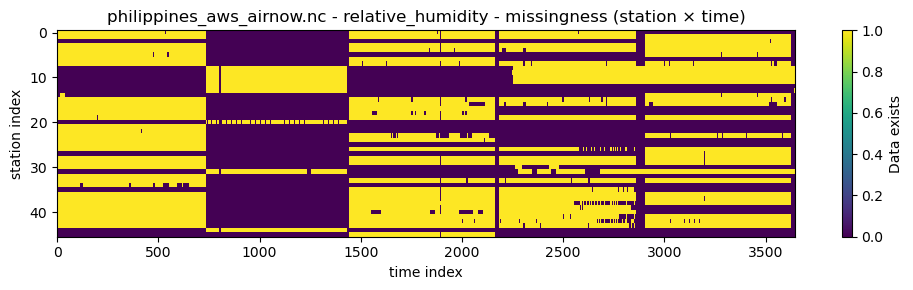

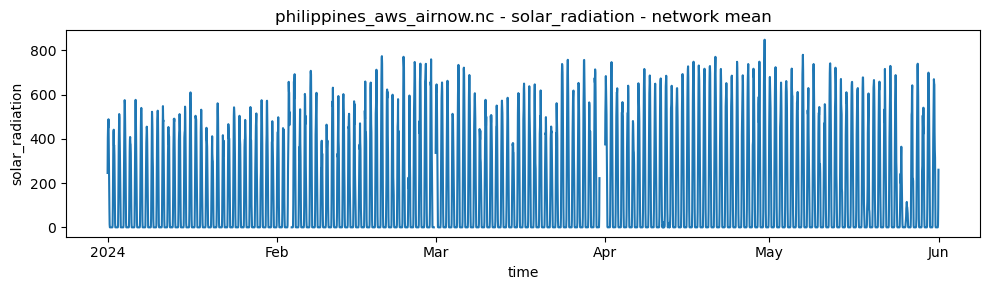

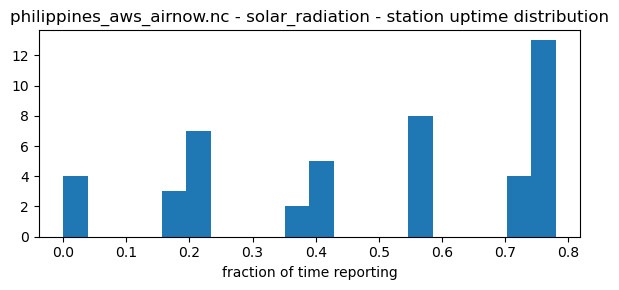

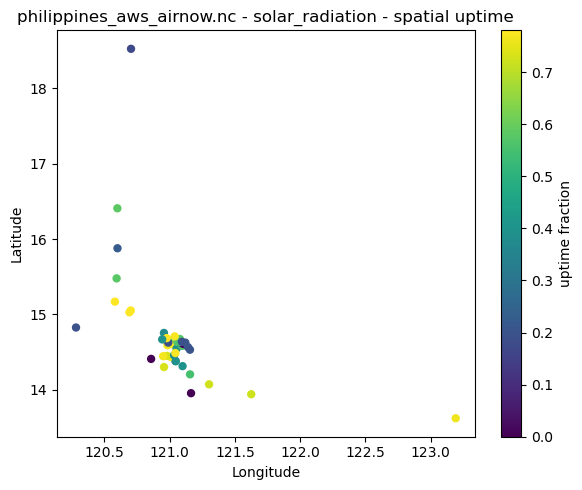

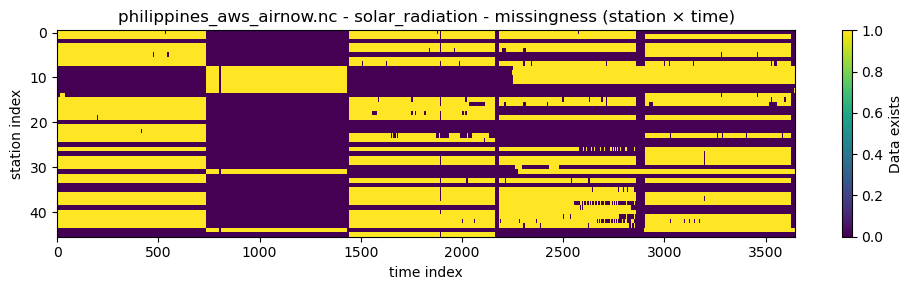

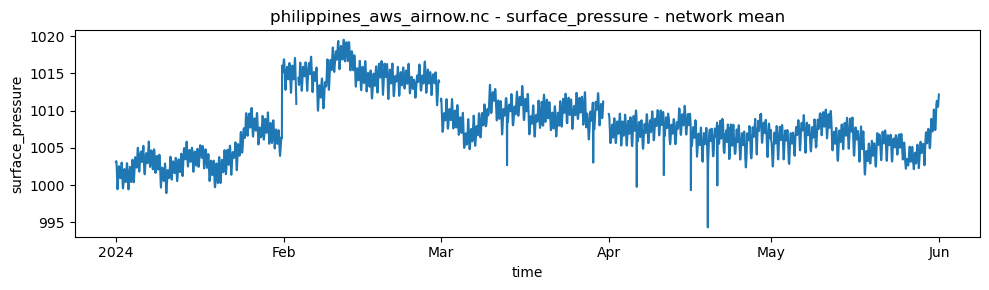

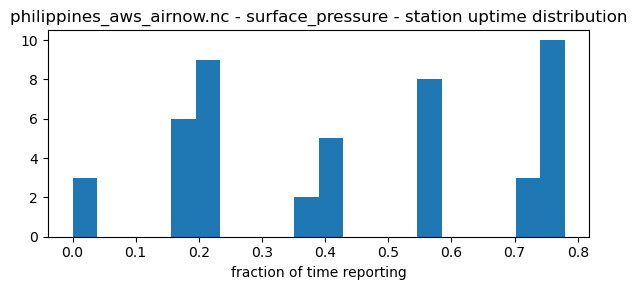

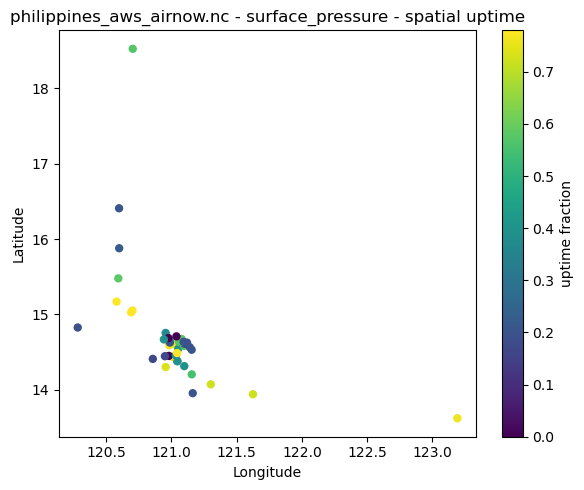

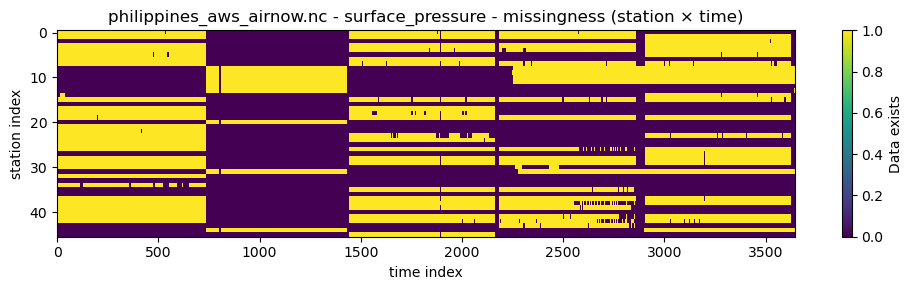

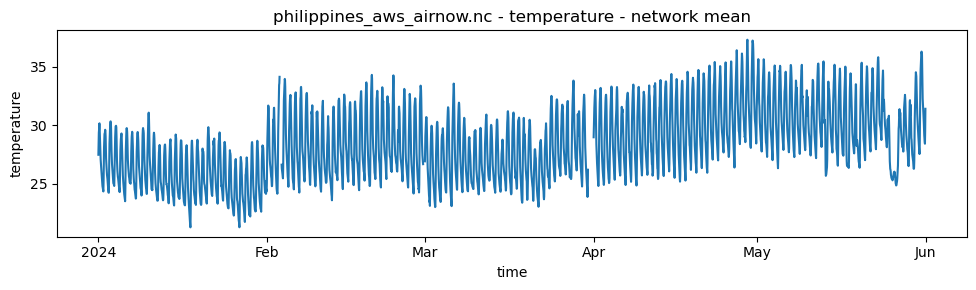

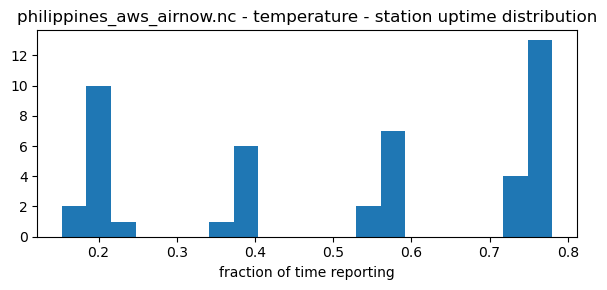

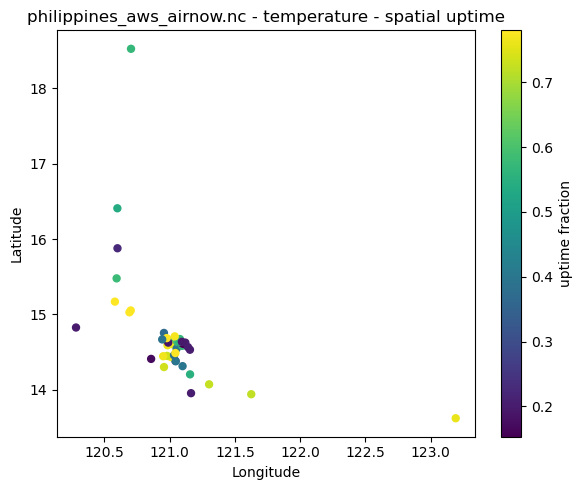

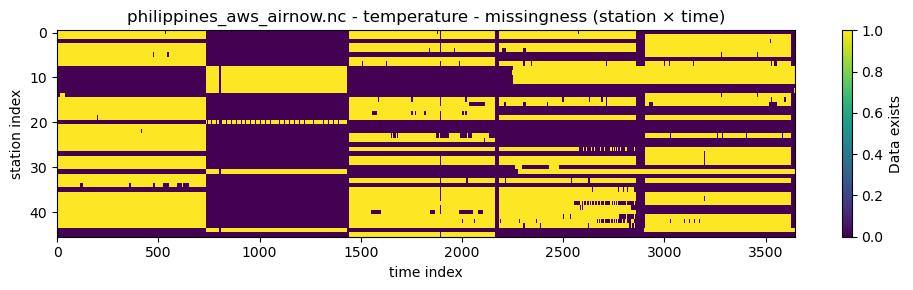

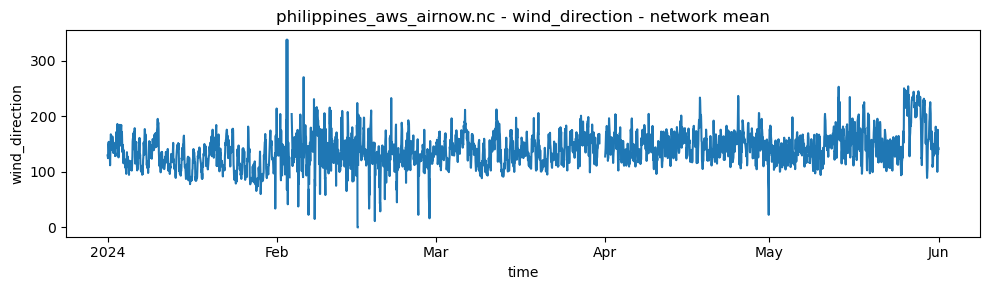

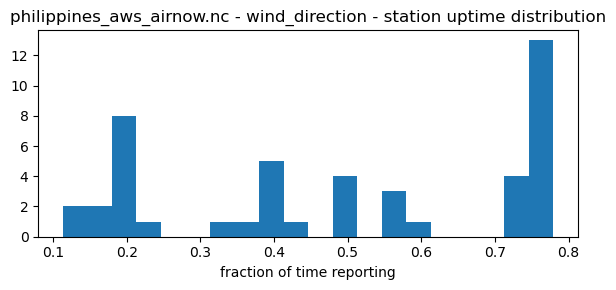

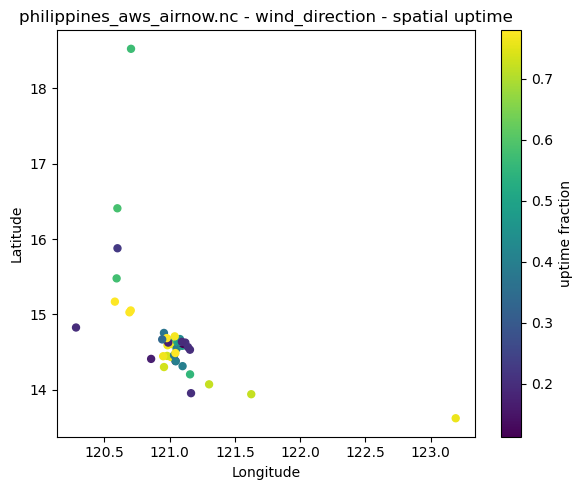

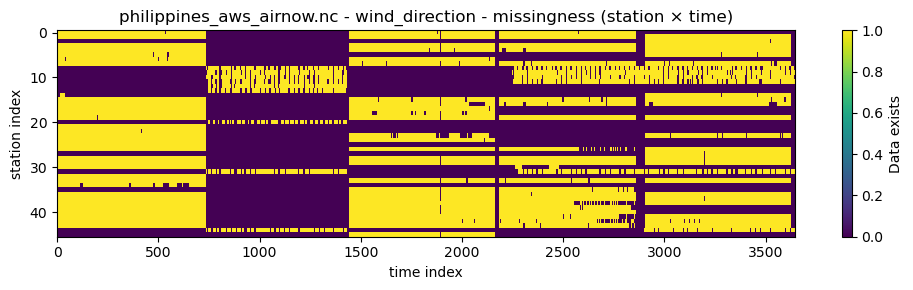

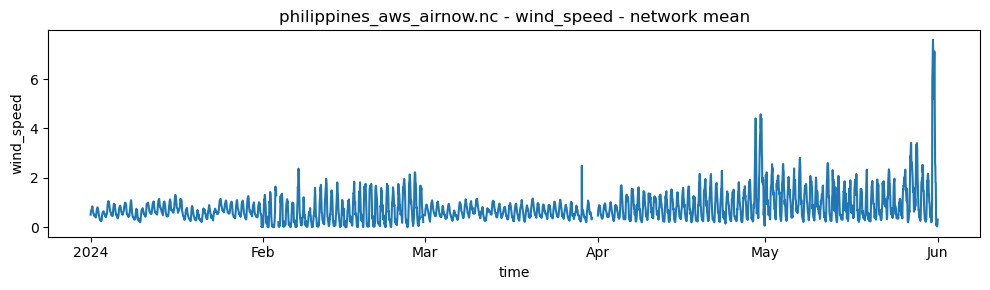

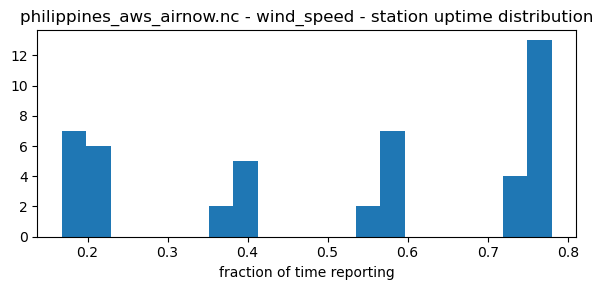

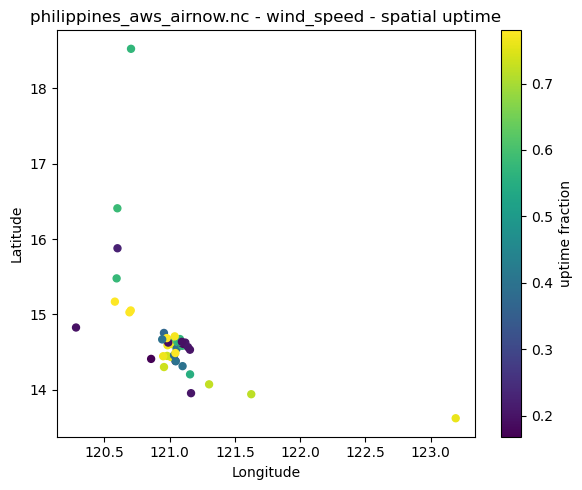

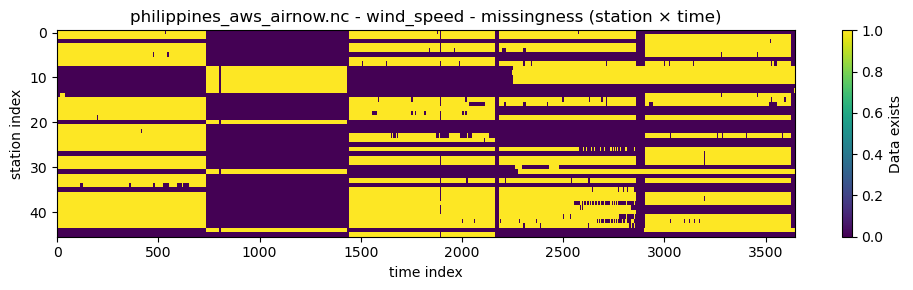

In [9]:

def inspect_dataset(ds, name=""):
    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    print(ds)

    print("\nDIMS")
    print(ds.dims)

    print("\nCOORDS")
    print(list(ds.coords))

    print("\nVARIABLES")
    print(list(ds.data_vars))

    return ds

# def completeness(ds):
#     nx, nt = ds.sizes["x"], ds.sizes["time"]
#     print(f"\ngrid: {nx} sites x {nt} times = {nx*nt:,} cells")
#     for v in ds.data_vars:
#         da = ds[v]
#         if not np.issubdtype(da.dtype, np.number):
#             continue
#         n = int(da.notnull().sum())
#         per_site = da.notnull().sum("time")          # number of valid obs per site
#         live = int((per_site > 0).sum())
#         print(f"  {v:20s} {n:>10,} ({100*n/(nx*nt):5.1f}%)  "
#               f"live sites: {live}/{nx}")

def qc_report(ds):

    # check that the site measured every variable during temporal period, and get the time period the station was up for
    nt = ds.sizes["time"]
    nx = ds.sizes["x"]

    print(f"\ngrid: {nx} stations x {nt} times")

    for v in ds.data_vars:
        da = ds[v]

        if not np.issubdtype(da.dtype, np.number):
            continue

        mask = da.notnull()

        # check instrument available
        instrument = mask.any("time")

        # temporal uptime
        uptime = mask.mean("time")

        # station-level summary
        active_sites = instrument.sum().item()

        # completeness
        overall = mask.mean().item()

        print(f"\n{v}")
        print(f"  overall completeness   : {overall:6.2%}")
        print(f"  active stations        : {active_sites}/{nx}")
        print(f"  mean uptime (active)   : {uptime.where(instrument).mean().item():6.2%}")
        
def check_mm_ready(ds):
    assert "x" in ds.dims and "time" in ds.dims, ds.sizes
    assert np.issubdtype(ds["time"].dtype, np.datetime64), ds["time"].dtype
    for c in ("siteid", "latitude", "longitude"):
        assert c in ds.coords, f"missing {c}"
    bad = int(ds["latitude"].isnull().sum())
    print(f"MM-ready  ({bad} sites with no coords)")

def qc_plots(ds, var_list=None, title_prefix=""):
    
    if var_list is None:
        var_list = [
            v for v in ds.data_vars
            if np.issubdtype(ds[v].dtype, np.number)
        ]

    for var in var_list:
        da = ds[var]

        if "x" not in da.dims or "time" not in da.dims:
            continue

        mask = da.notnull()

       # mean ts
        plt.figure(figsize=(10, 3))
        da.mean("x", skipna=True).plot()
        plt.title(f"{title_prefix}{var} - network mean")
        plt.tight_layout()
        plt.show()

        # station uptime
        uptime = mask.mean("time")

        plt.figure(figsize=(6, 3))
        uptime.plot.hist(bins=20)
        plt.title(f"{title_prefix}{var} - station uptime distribution")
        plt.xlabel("fraction of time reporting")
        plt.tight_layout()
        plt.show()

# spatial uptime 
        plt.figure(figsize=(6, 5))
        plt.scatter(
            ds["longitude"],
            ds["latitude"],
            c=uptime,
            cmap="viridis",
            s=25
        )
        plt.colorbar(label="uptime fraction")
        plt.title(f"{title_prefix}{var} - spatial uptime")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.tight_layout()
        plt.show()
        
# missing heatmap 
        plt.figure(figsize=(10, 3))
        plt.imshow(mask.T, aspect="auto", interpolation="none")
        plt.colorbar(label="Data exists")
        plt.title(f"{title_prefix}{var} - missingness (station × time)")
        plt.xlabel("time index")
        plt.ylabel("station index")
        plt.tight_layout()
        plt.show()

datasets = []

for f in FILES:

    print("\n" + "="*100)
    print("PROCESSING:", f)
    print("="*100)

    # load
    ds = xr.open_dataset(f)
    ds = ds.sel(time=slice("2024-01-01", "2024-05-31 23:59:59"))

    # inspect 
    ds = inspect_dataset(ds, f)

    qc_report(ds)
    check_mm_ready(ds)

    datasets.append(ds)

    qc_plots(ds, title_prefix=f"{f.split('/')[-1]} - ")